In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

# Check temporal pattern of east vs. west observations

# "Does one region have observations that are more or less recent than the other region?"

In [2]:
data = pd.read_csv('../datasets/geo_med.csv')
occ_data = pd.read_table('../raw_data/0002206-250218110819086/occurrence.txt',sep='\t')

/var/folders/qh/c7rwx84921n2kznn09zb2pnh0000gn/T/ipykernel_34889/1326294688.py:2: DtypeWarning: Columns (20,29,139,170) have mixed types. Specify dtype option on import or set low_memory=False.
  occ_data = pd.read_table('../raw_data/0002206-250218110819086/occurrence.txt',sep='\t')


In [3]:
west_data = data[data.longitude < -100]
east_data = data[data.longitude > -100]

# Average year

### "If we average all of the *year* values across the images for west vs. east, do we get the same value?"

In [4]:
obs_years_west = []
for gbifID in west_data.gbifID:
    cur_row = occ_data[occ_data.gbifID.eq(gbifID)]
    obs_year = cur_row.year.iloc[0]
    obs_years_west.append(obs_year)
    
obs_years_east = []
for gbifID in east_data.gbifID:
    cur_row = occ_data[occ_data.gbifID.eq(gbifID)]
    obs_year = cur_row.year.iloc[0]
    obs_years_east.append(obs_year)

In [5]:
# What is the average year of images taken from the west?
np.mean(obs_years_west)

np.float64(2021.411343097538)

In [6]:
# What is the average year of images taken from the east?
np.mean(obs_years_east)

np.float64(2021.4065675411907)

### These are about the same, so we are concluding that there is no temporal difference in observations between the regions.

# Average day of year

### "If we average all of the *day of year* values across the images for west vs. east, do we get the same value?"

### Note: this will reflect phenological differences between west and east

In [7]:
obs_days_west = []
for gbifID in west_data.gbifID:
    cur_row = occ_data[occ_data.gbifID.eq(gbifID)]
    obs_day = cur_row.startDayOfYear.iloc[0]
    obs_days_west.append(obs_day)
    
obs_days_east = []
for gbifID in east_data.gbifID:
    cur_row = occ_data[occ_data.gbifID.eq(gbifID)]
    obs_day = cur_row.startDayOfYear.iloc[0]
    obs_days_east.append(obs_day)

In [8]:
np.mean(obs_days_west)

np.float64(199.93206606419446)

In [9]:
np.mean(obs_days_east)

np.float64(198.60772719444284)

# Across the full data, do we see any trends in color across years?

In [10]:
years = []
for gbifID in data.gbifID:
    cur_row = occ_data[occ_data.gbifID.eq(gbifID)]
    obs_year = cur_row.year.iloc[0]
    years.append(obs_year)
data['year'] = years

### Get the component averages

In [11]:
L_avgs = []
L_stds = []

a_avgs = []
a_stds = []

b_avgs = []
b_stds = []
for year in range(2008,2025):
    subset_lab = data[data.year.eq(year)].lab
    L_vals = [ast.literal_eval(i)[0] for i in subset_lab]
    a_vals = [ast.literal_eval(i)[1] for i in subset_lab]
    b_vals = [ast.literal_eval(i)[2] for i in subset_lab]
    
    L_avgs.append(float(np.mean(L_vals)))
    L_stds.append(float(np.std(L_vals)))
    
    a_avgs.append(float(np.mean(a_vals)))
    a_stds.append(float(np.std(a_vals)))
    
    b_avgs.append(float(np.mean(b_vals)))
    b_stds.append(float(np.std(b_vals)))

# Does *L* change through time?

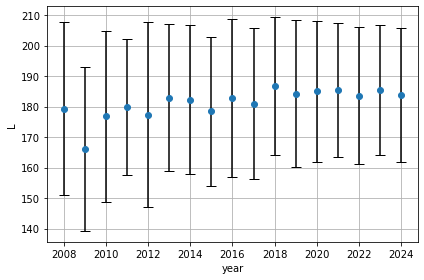

In [12]:
x = range(2008,2025)

plt.errorbar(x, L_avgs, yerr=L_stds, fmt='o', capsize=5, ecolor='black', linestyle='none')
plt.xlabel('year')
plt.ylabel('L')
plt.grid(True)
plt.tight_layout()
plt.show()

# Does *a* change through time?

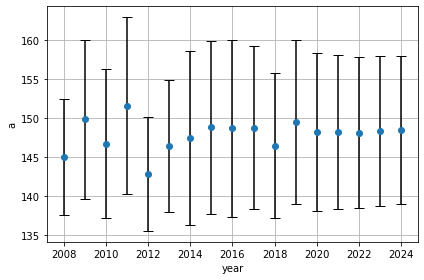

In [13]:
plt.errorbar(x, a_avgs, yerr=a_stds, fmt='o', capsize=5, ecolor='black', linestyle='none')
plt.xlabel('year')
plt.ylabel('a')
plt.grid(True)
plt.tight_layout()
plt.show()

# Does *b* change through time?

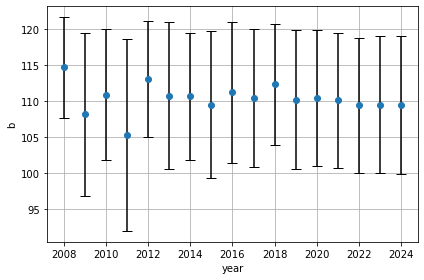

In [14]:
plt.errorbar(x, b_avgs, yerr=b_stds, fmt='o', capsize=5, ecolor='black', linestyle='none')
plt.xlabel('year')
plt.ylabel('b')
plt.grid(True)
plt.tight_layout()
plt.show()